In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


<h3>Create a dataset using the relationship:<br/> y=14x + 30</h3>
<p>Make a contrived data set from a known linear relationship to see if we can recover said relationship using linear regression.</p>

In [ ]:
np.random.seed(3)

with open("grades.csv", "w") as f:
    
    f.write("id,hours,grade\n" )

    for i in range(1,100):

        # Generate a 'name' for this student
        id = 100 + i    # This does not matter

        # Generate a random number between 0-5 (the number of hours studied)
        hours = np.random.uniform(0, 5)

        # Generate some normally distributed noise, centered at 0
        # with a standard deviation of 5
        noise = np.random.normal(0,15)

        # Make our linear relationship, with some added noise
        # The contrived linear relationship we are trying to recover is
        # y = 14x + 30
        grade = hours * 14 + 30 + noise
        if grade > 100:
            grade = 100
        if grade < 0:
            grade = 0

        # Generate a row for this student, the hours studied, and their grade.
        f.write(f"{id},{hours:.2f},{grade:.0f}\n")
    
        
    f.close()


gradebook = pd.read_csv("grades.csv")
gradebook




,id,hours,grade
0,101,2.75,53
1,102,2.55,81
2,103,4.46,86
3,104,2.28,61
4,105,3.25,90
...,...,...,...
94,195,2.31,70
95,196,3.98,72
96,197,2.89,57
97,198,0.23,57


<h3>Estimate the linear relationship using Linear Regression</h3>

Estimated linear relationship:
 y = 13.64 (x) + 29.48


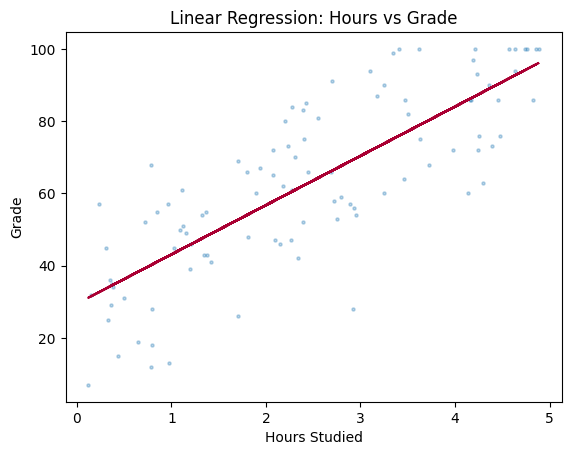

In [6]:
from sklearn.linear_model import LinearRegression

# Load data
gradebook = pd.read_csv("grades.csv")

# Define features and target
X = gradebook[["hours"]]   # Must be a list of predictors (not a single predictor, even
y = gradebook["grade"]     #         though our 'list' only contains a single variable)


# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Print coefficients
print(f"Estimated linear relationship:")
print(f" y = {model.coef_[0]:0.2f} (x) + {model.intercept_:0.2f}")

# Plot
plt.scatter(gradebook["hours"], gradebook["grade"], s=5, alpha=0.3)
plt.plot(gradebook["hours"], y_pred, color="#a03")
plt.xlabel("Hours Studied")
plt.ylabel("Grade")
plt.title("Linear Regression: Hours vs Grade")
plt.show()

<h3>This technique can be scaled to an arbitrary number of predictive dimensions<br/>Here, we create a dataset using the relationship:<br/><br/> y=14 x<sub>1</sub> + 0.5 x<sub>2</sub> + 30</h3>
<p>In this example, we will assume a student gets 14 points for each hour of independent study, and 0.5 points for each hour of study with a tutor, a baseline score of 30 if they did not study at all, and some random noise to simulate a distribution of scores around what would otherwise be a strictly linear relationship.</p>

In [8]:
np.random.seed(9) # For reproducibility with examples

with open("grades-2D.csv", "w") as f:
    
    f.write("id,hours,tutor,grade\n" )

    for i in range(1,1000):

        # Make the student's "name"
        id = 100 + i # This doesn't matter. At all.

        # Generate random numbers between 0-5 (the number of hours studied) and 0-1 (tutoring hours)
        study_hours = np.random.uniform(0, 4)
        tutoring_hours = np.random.uniform(0, 1)

        # Generate some normally distributed noise, centered at 0
        # with a standard deviation of 5
        noise = np.random.normal(0,5)


        # Make our linear relationship, with some added noise
        # The contrived linear relationship we will later try to recover is
        # y = 14 (x1) + 0.5 (x2) + 30

        grade = study_hours * 14 + 0.5*(tutoring_hours) + 30 + noise
        
        # if grade > 100:
        #     grade = 100
        if grade < 0:
            grade = 0

        # Generate a row for this student, indicating the hours of independent study
        # the hours of tutoring, and their grade.
        
        f.write(f"{id},{study_hours:.2f},{tutoring_hours:.2f},{grade:.0f}\n")
    
    f.close()

gradebook = pd.read_csv("grades-2D.csv")
gradebook

,id,hours,tutor,grade
0,101,0.04,0.50,25
1,102,0.57,0.22,38
2,103,1.67,0.25,52
3,104,0.67,0.88,37
4,105,3.80,0.04,86
...,...,...,...,...
994,1095,4.00,0.80,89
995,1096,0.48,0.38,39
996,1097,1.52,0.61,48
997,1098,1.20,0.51,55


<h3>Estimate the linear relationship using Linear Regression</h3>

Estimated linear relationship:
 y = 14.17 (x1) + 0.64 (x2) + 29.66


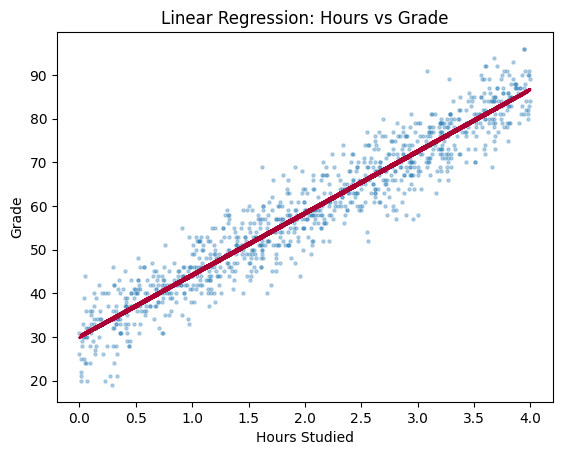

In [7]:
from sklearn.linear_model import LinearRegression

# Load data
gradebook = pd.read_csv("grades-2D.csv")

# Define features and target
X = gradebook[["hours","tutor"]]   # Here, our list specifies 2 predictive variables
y = gradebook["grade"]

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Print coefficients
print(f"Estimated linear relationship:")
print(f" y = {model.coef_[0]:0.2f} (x1) + {model.coef_[1]:0.2f} (x2) + {model.intercept_:0.2f}")

# Plot
plt.scatter(gradebook["hours"], gradebook["grade"], s=5, alpha=0.3)
plt.plot(gradebook["hours"], y_pred, color="#a03")
plt.xlabel("Hours Studied")
plt.ylabel("Grade")
plt.title("Linear Regression: Hours vs Grade")
plt.show()